In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import seisbench.data as sbd

import matplotlib.pyplot as plt

/home/namithk/miniconda3/envs/eew/lib/python3.9/site-packages/seisbench/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
dataset = sbd.STEAD()
metadata = dataset.metadata

# ---- FILTER ----
eq_mask = (
    (metadata["trace_category"] == "earthquake_local") &
    (metadata["trace_p_arrival_sample"].notna()) &
    (metadata["trace_s_arrival_sample"].notna()) &
    (metadata["trace_p_arrival_sample"] < 3000) &
    (metadata["trace_s_arrival_sample"] < 3000)
)

noise_mask = metadata["trace_category"] == "noise"

filtered_metadata = metadata[eq_mask | noise_mask]  # DO NOT reset index

print("Filtered:", len(filtered_metadata))

# Balanced subset
eq_data = filtered_metadata[filtered_metadata["trace_category"]=="earthquake_local"]
noise_data = filtered_metadata[filtered_metadata["trace_category"]=="noise"]

eq_subset = eq_data.sample(n=40000, random_state=42)
noise_subset = noise_data.sample(n=10000, random_state=42)

subset_metadata = pd.concat([eq_subset, noise_subset])  # keep original indices

2026-04-22 14:37:18,129 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.


Filtered: 1239998


In [4]:
def compute_sta_lta(waveform, sta=50, lta=500, eps=1e-8):
    energy = np.sum(waveform**2, axis=0)
    sta_vals = np.convolve(energy, np.ones(sta)/sta, mode="same")
    lta_vals = np.convolve(energy, np.ones(lta)/lta, mode="same")
    ratio = sta_vals / (lta_vals + eps)
    ratio = ratio / (np.max(ratio) + eps)
    return ratio.astype(np.float32)


def gaussian_pick_p(arrival, length=3000, sigma=8):
    t = np.arange(length)
    return np.exp(-(t-arrival)**2/(2*sigma**2)).astype(np.float32)


def gaussian_pick_s(arrival, length=3000, sigma=20):
    t = np.arange(length)
    return np.exp(-(t-arrival)**2/(2*sigma**2)).astype(np.float32)

In [5]:
class Phase2Dataset(Dataset):
    def __init__(self, dataset, metadata):
        self.dataset = dataset
        self.metadata = metadata

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):

        meta = self.metadata.iloc[idx]
        real_idx = meta.name   # IMPORTANT FIX

        # waveform
        wf = self.dataset.get_waveforms([real_idx])[0][:,:3000].astype(np.float32)

        # normalization (IMPORTANT)
        wf = wf - wf.mean(axis=1, keepdims=True)
        wf = wf / (wf.std(axis=1, keepdims=True) + 1e-6)

        # detection label
        y_det = 1.0 if meta["trace_category"]=="earthquake_local" else 0.0

        # STA/LTA (scaled)
        sta_lta = compute_sta_lta(wf)
        sta_lta = (sta_lta - sta_lta.mean()) / (sta_lta.std() + 1e-6)
        sta_lta = np.clip(sta_lta, -3, 3)

        x = np.vstack([wf, 0.3 * sta_lta])

        # phase targets
        if y_det == 1.0:
            p_arr = int(meta["trace_p_arrival_sample"])
            s_arr = int(meta["trace_s_arrival_sample"])
            y_p = gaussian_pick_p(p_arr)
            y_s = gaussian_pick_s(s_arr)
        else:
            y_p = np.zeros(3000, dtype=np.float32)
            y_s = np.zeros(3000, dtype=np.float32)

        return (
            torch.from_numpy(x),
            torch.tensor([y_det], dtype=torch.float32),
            torch.from_numpy(y_p),
            torch.from_numpy(y_s)
        )

In [6]:
train_dataset = Phase2Dataset(dataset, subset_metadata)

loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

In [7]:
from models import ResidualBlock

class Phase2MultiTaskTCN(nn.Module):
    def __init__(self):
        super().__init__()

        self.input_conv = nn.Conv1d(4, 32, kernel_size=1)

        dilations = [1,2,4,8,16,32,64,128]
        self.blocks = nn.Sequential(
            *[ResidualBlock(32,5,d) for d in dilations]
        )

        # detection
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32,1)

        # phase heads (FIXED)
        self.p_head = nn.Sequential(
            nn.Conv1d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 1, 1)
        )

        self.s_head = nn.Sequential(
            nn.Conv1d(32, 32, 7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 1, 1)
        )

    def forward(self, x):

        x = self.input_conv(x)
        features = self.blocks(x)

        det = self.pool(features).squeeze(-1)
        det = self.fc(det)

        # NO sigmoid (IMPORTANT)
        p_map = self.p_head(features).squeeze(1)
        s_map = self.s_head(features).squeeze(1)

        return det, p_map, s_map

In [8]:
model = Phase2MultiTaskTCN()

checkpoint = torch.load("../res_models/backbone_models/checkpoint_epoch9.pth")
state_dict = checkpoint["model_state_dict"]

model.input_conv.weight.data[:, :3] = state_dict["input_conv.weight"]
model.input_conv.bias.data = state_dict["input_conv.bias"]

blocks_state = {
    k.replace("blocks.", ""): v
    for k,v in state_dict.items() if k.startswith("blocks.")
}
model.blocks.load_state_dict(blocks_state)

model.fc.weight.data = state_dict["fc.weight"]
model.fc.bias.data = state_dict["fc.bias"]

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# freeze backbone initially
for p in model.blocks.parameters():
    p.requires_grad = False
for p in model.input_conv.parameters():
    p.requires_grad = False

det_loss_fn = nn.BCEWithLogitsLoss()
phase_loss_fn = nn.MSELoss(reduction='none')

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

In [10]:
# for epoch in range(5):

#     model.train()
#     total_loss = 0

#     for x, y_det, y_p, y_s in loader:

#         x = x.to(device)
#         y_det = y_det.to(device)
#         y_p = y_p.to(device)
#         y_s = y_s.to(device)

#         optimizer.zero_grad()

#         det_out, p_out, s_out = model(x)

#         # detection loss
#         L_det = det_loss_fn(det_out, y_det)

#         # phase losses (MSE)
#         L_p_raw = phase_loss_fn(p_out, y_p)
#         L_s_raw = phase_loss_fn(s_out, y_s)

#         # weighting
#         p_weight = 1 + 20*y_p
#         s_weight = 1 + 20*y_s

#         L_p = (L_p_raw * p_weight).mean()
#         L_s = (L_s_raw * s_weight).mean()

#         # ---- peak loss (masked) ----
#         eq_mask = y_det.squeeze(1) > 0.5

#         if eq_mask.sum() > 0:
#             p_pred_idx = torch.argmax(p_out[eq_mask], dim=1)
#             s_pred_idx = torch.argmax(s_out[eq_mask], dim=1)

#             p_true_idx = torch.argmax(y_p[eq_mask], dim=1)
#             s_true_idx = torch.argmax(y_s[eq_mask], dim=1)

#             L_peak = F.l1_loss(p_pred_idx.float(), p_true_idx.float()) + \
#                      F.l1_loss(s_pred_idx.float(), s_true_idx.float())
#         else:
#             L_peak = torch.tensor(0.0, device=device)
        

#         # ---- MAE tracking ----
#         P_error = torch.abs(p_pred_idx - p_true_idx).float().mean()
#         S_error = torch.abs(s_pred_idx - s_true_idx).float().mean()

#         # ---- Physics constraint: P < S ----
#         if eq_mask.sum() > 0:
#             p_idx = p_pred_idx.float()
#             s_idx = s_pred_idx.float()

#             L_order = torch.mean(F.relu(p_idx - s_idx + 5))  # margin = 5
#         else:
#             L_order = torch.tensor(0.0, device=device)

#         # final loss
#         # loss = L_det + 2*L_p + 2*L_s + 0.5*L_peak
#         loss = L_det + 2*L_p + 2*L_s + 0.5*L_peak + 0.5*L_order
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     # print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.4f}")
#     print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.4f} | P_MAE: {P_error.item():.2f} | S_MAE: {S_error.item():.2f}")

In [ ]:
# for epoch in range(7):

#     model.train()
#     total_loss = 0

#     # ---- MAE tracking across epoch ----
#     total_P_error = 0
#     total_S_error = 0
#     count = 0

#     for x, y_det, y_p, y_s in loader:

#         x = x.to(device)
#         y_det = y_det.to(device)
#         y_p = y_p.to(device)
#         y_s = y_s.to(device)

#         optimizer.zero_grad()

#         det_out, p_out, s_out = model(x)

#         # ---- detection loss ----
#         L_det = det_loss_fn(det_out, y_det)

#         # ---- phase losses (MSE) ----
#         L_p_raw = phase_loss_fn(p_out, y_p)
#         L_s_raw = phase_loss_fn(s_out, y_s)

#         # ---- weighting ----
#         p_weight = 1 + 20*y_p
#         s_weight = 1 + 20*y_s

#         L_p = (L_p_raw * p_weight).mean()
#         L_s = (L_s_raw * s_weight).mean()

#         # ---- peak + MAE + physics (masked) ----
#         eq_mask = y_det.squeeze(1) > 0.5

#         if eq_mask.sum() > 0:
#             p_pred_idx = torch.argmax(p_out[eq_mask], dim=1)
#             s_pred_idx = torch.argmax(s_out[eq_mask], dim=1)

#             p_true_idx = torch.argmax(y_p[eq_mask], dim=1)
#             s_true_idx = torch.argmax(y_s[eq_mask], dim=1)

#             # peak loss
#             L_peak = F.l1_loss(p_pred_idx.float(), p_true_idx.float()) + \
#                      F.l1_loss(s_pred_idx.float(), s_true_idx.float())

#             # MAE tracking
#             P_error = torch.abs(p_pred_idx - p_true_idx).float().mean()
#             S_error = torch.abs(s_pred_idx - s_true_idx).float().mean()

#             total_P_error += P_error.item()
#             total_S_error += S_error.item()
#             count += 1

#             # physics constraint: P < S
#             L_order = torch.mean(F.relu(p_pred_idx.float() - s_pred_idx.float() + 5))

#         else:
#             L_peak = torch.tensor(0.0, device=device)
#             L_order = torch.tensor(0.0, device=device)

#         # ---- final loss ----
#         loss = L_det + 2*L_p + 2*L_s + 0.5*L_peak + 0.5*L_order

#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     # ---- epoch metrics ----
#     avg_P = total_P_error / max(count, 1)
#     avg_S = total_S_error / max(count, 1)

#     print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.4f} | P_MAE: {avg_P:.2f} | S_MAE: {avg_S:.2f}")

Epoch 1 | Loss: 161.5268 | P_MAE: 142.73 | S_MAE: 154.67
Epoch 2 | Loss: 129.5059 | P_MAE: 100.32 | S_MAE: 135.95
Epoch 3 | Loss: 121.7903 | P_MAE: 93.06 | S_MAE: 130.44
Epoch 4 | Loss: 119.6869 | P_MAE: 91.51 | S_MAE: 126.59
Epoch 5 | Loss: 116.0269 | P_MAE: 89.03 | S_MAE: 122.33
Epoch 6 | Loss: 114.2704 | P_MAE: 86.97 | S_MAE: 121.92
Epoch 7 | Loss: 114.6668 | P_MAE: 87.33 | S_MAE: 121.41


In [33]:
for epoch in range(7):

    model.train()
    total_loss = 0

    # ---- MAE tracking across epoch ----
    total_P_error = 0
    total_S_error = 0
    count = 0

    for x, y_det, y_p, y_s in loader:

        x = x.to(device)
        y_det = y_det.to(device)
        y_p = y_p.to(device)
        y_s = y_s.to(device)

        optimizer.zero_grad()

        det_out, p_out, s_out = model(x)

        # ---- detection loss ----
        L_det = det_loss_fn(det_out, y_det)

        # ---- phase losses (MSE) ----
        L_p_raw = phase_loss_fn(p_out, y_p)
        L_s_raw = phase_loss_fn(s_out, y_s)

        # ---- weighting ----
        p_weight = 1 + 20*y_p
        s_weight = 1 + 20*y_s

        L_p = (L_p_raw * p_weight).mean()
        L_s = (L_s_raw * s_weight).mean()

        # ---- peak + MAE + physics + sharpening (masked) ----
        eq_mask = y_det.squeeze(1) > 0.5

        if eq_mask.sum() > 0:
            p_pred_idx = torch.argmax(p_out[eq_mask], dim=1)
            s_pred_idx = torch.argmax(s_out[eq_mask], dim=1)

            p_true_idx = torch.argmax(y_p[eq_mask], dim=1)
            s_true_idx = torch.argmax(y_s[eq_mask], dim=1)

            # ---- peak loss ----
            L_peak = F.l1_loss(p_pred_idx.float(), p_true_idx.float()) + \
                     F.l1_loss(s_pred_idx.float(), s_true_idx.float())

            # ---- MAE tracking ----
            P_error = torch.abs(p_pred_idx - p_true_idx).float().mean()
            S_error = torch.abs(s_pred_idx - s_true_idx).float().mean()

            total_P_error += P_error.item()
            total_S_error += S_error.item()
            count += 1

            # ---- physics constraint: P < S ----
            L_order = torch.mean(F.relu(p_pred_idx.float() - s_pred_idx.float() + 5))

            # ---- sharpening loss (NEW) ----
            L_sharp = torch.mean((p_out[eq_mask] - y_p[eq_mask])**2) + \
                      torch.mean((s_out[eq_mask] - y_s[eq_mask])**2)

        else:
            L_peak = torch.tensor(0.0, device=device)
            L_order = torch.tensor(0.0, device=device)
            L_sharp = torch.tensor(0.0, device=device)

        # ---- final loss ----
        loss = L_det + 2*L_p + 2*L_s + 1.0*L_peak + 0.5*L_order + 0.3*L_sharp

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # ---- epoch metrics ----
    avg_P = total_P_error / max(count, 1)
    avg_S = total_S_error / max(count, 1)

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.4f} | P_MAE: {avg_P:.2f} | S_MAE: {avg_S:.2f}")

Epoch 1 | Loss: 211.0998 | P_MAE: 88.19 | S_MAE: 111.03
Epoch 2 | Loss: 210.2794 | P_MAE: 86.87 | S_MAE: 111.79
Epoch 3 | Loss: 211.8553 | P_MAE: 88.19 | S_MAE: 111.25
Epoch 4 | Loss: 213.4287 | P_MAE: 89.76 | S_MAE: 110.32
Epoch 5 | Loss: 210.8161 | P_MAE: 88.23 | S_MAE: 110.15
Epoch 6 | Loss: 212.0095 | P_MAE: 89.14 | S_MAE: 110.13
Epoch 7 | Loss: 212.6428 | P_MAE: 91.29 | S_MAE: 107.89



Sample 0
Detection Prob: 1.0000
P pred: 651
S pred: 1851

Sample 1
Detection Prob: 1.0000
P pred: 2779
S pred: 832

Sample 2
Detection Prob: 0.0140
No earthquake → Ignore P & S

Sample 3
Detection Prob: 1.0000
P pred: 782
S pred: 1421


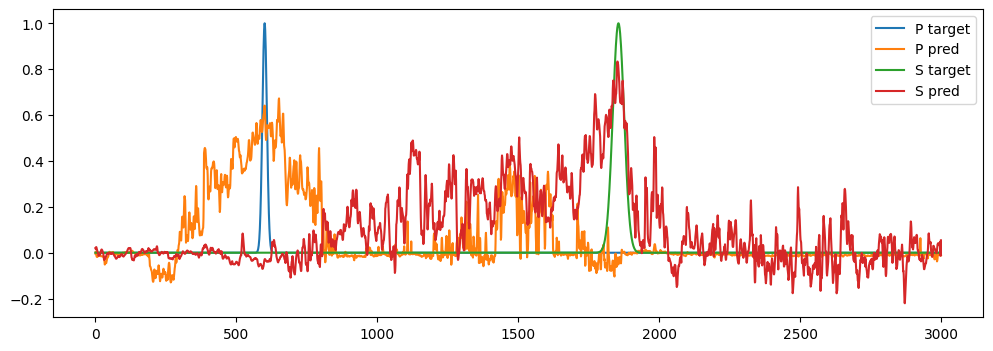

P pred: 651
P true: 600
S pred: 1851
S true: 1855


In [34]:
model.eval()

x, y_det, y_p, y_s = next(iter(loader))
x = x.to(device)

with torch.no_grad():
    det_out, p_out, s_out = model(x)

det_prob = torch.sigmoid(det_out)

for i in range(len(det_prob)):

    print(f"\nSample {i}")
    print(f"Detection Prob: {det_prob[i].item():.4f}")

    if det_prob[i] > 0.5:
        p_idx = torch.argmax(p_out[i]).item()
        s_idx = torch.argmax(s_out[i]).item()

        print(f"P pred: {p_idx}")
        print(f"S pred: {s_idx}")
    else:
        print("No earthquake → Ignore P & S")
idx = 0

plt.figure(figsize=(12,4))
plt.plot(y_p[idx].cpu(), label="P target")
plt.plot(p_out[idx].cpu(), label="P pred")
plt.plot(y_s[idx].cpu(), label="S target")
plt.plot(s_out[idx].cpu(), label="S pred")
plt.legend()
plt.show()

print("P pred:", torch.argmax(p_out[idx]).item())
print("P true:", torch.argmax(y_p[idx]).item())
print("S pred:", torch.argmax(s_out[idx]).item())
print("S true:", torch.argmax(y_s[idx]).item())


========== SAMPLE 0 ==========
True Label: 1.0
Detection Prob: 1.0000
Predicted P: 905
Predicted S: 1551
True P: 898
True S: 1543


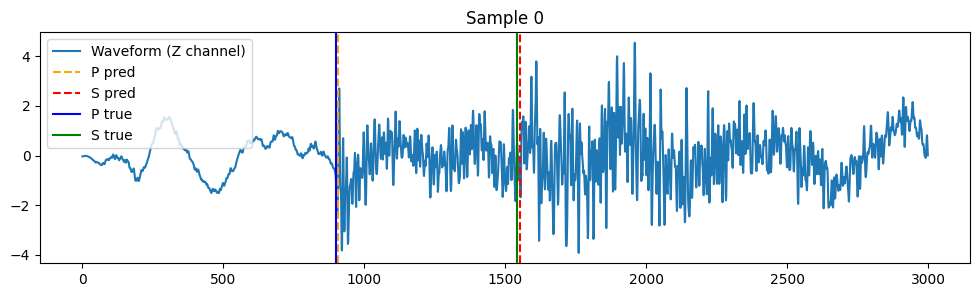


========== SAMPLE 1 ==========
True Label: 1.0
Detection Prob: 1.0000
Predicted P: 908
Predicted S: 1090
True P: 900
True S: 1078


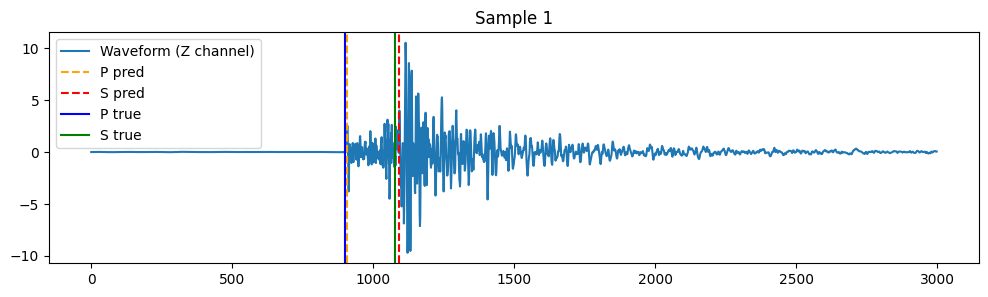


========== SAMPLE 2 ==========
True Label: 0.0
Detection Prob: 0.2911
No earthquake → Skipping P/S


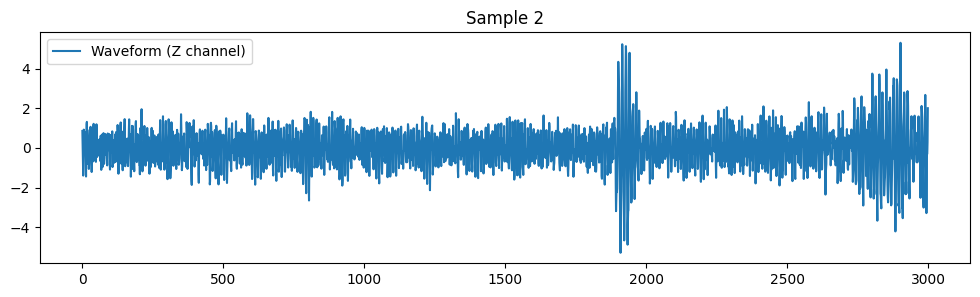


========== SAMPLE 3 ==========
True Label: 0.0
Detection Prob: 0.0008
No earthquake → Skipping P/S


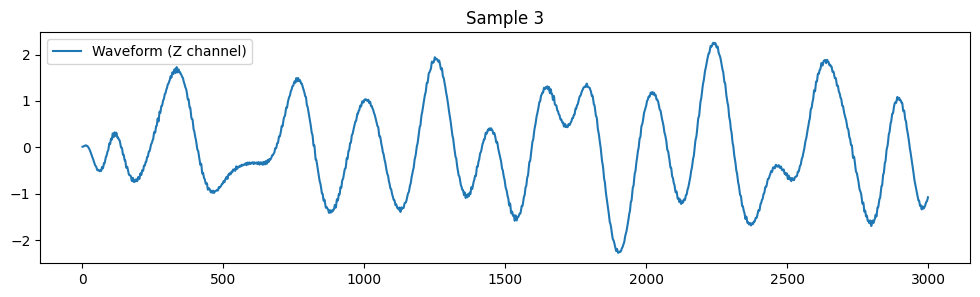

In [35]:
model.eval()

# get one batch
x, y_det, y_p, y_s = next(iter(loader))

x = x.to(device)

with torch.no_grad():
    det_out, p_out, s_out = model(x)

det_prob = torch.sigmoid(det_out)

num_samples = min(5, x.shape[0])

for i in range(num_samples):

    print(f"\n========== SAMPLE {i} ==========")
    print(f"True Label: {y_det[i].item()}")
    print(f"Detection Prob: {det_prob[i].item():.4f}")

    # ---- Plot waveform (Z channel only for clarity) ----
    waveform = x[i, 0].cpu().numpy()

    plt.figure(figsize=(12,3))
    plt.plot(waveform, label="Waveform (Z channel)")

    # ---- If earthquake detected ----
    if det_prob[i] > 0.5:

        p_idx = torch.argmax(p_out[i]).item()
        s_idx = torch.argmax(s_out[i]).item()

        print(f"Predicted P: {p_idx}")
        print(f"Predicted S: {s_idx}")

        # True indices
        p_true = torch.argmax(y_p[i]).item()
        s_true = torch.argmax(y_s[i]).item()

        print(f"True P: {p_true}")
        print(f"True S: {s_true}")

        # plot predicted + true
        plt.axvline(p_idx, color='orange', linestyle='--', label="P pred")
        plt.axvline(s_idx, color='red', linestyle='--', label="S pred")

        plt.axvline(p_true, color='blue', linestyle='-', label="P true")
        plt.axvline(s_true, color='green', linestyle='-', label="S true")

    else:
        print("No earthquake → Skipping P/S")

    plt.legend()
    plt.title(f"Sample {i}")
    plt.show()